# Classic cars as an asset class — a quantitative teardown 🔬
### Car index vs S&P, price-only AND total-return (CAGR / vol / MDD + annual-excess *t*) · the appraisal-smoothing de-bias · Newey-West proxy alpha · the auction-spread + carry haircut on NAV · a synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cars_beat_equities%3F: Busted](https://img.shields.io/badge/Cars_beat_equities%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest tradable form of "collector cars beat the S&P": (H₁) the collector-car index out-returns the S&P; (H₂) its low measured volatility survives de-smoothing; (H₃) a buyable proxy carries alpha vs the market; (H₄) it survives the cost of owning the metal. We find **H₁ rejected** (it *under*-performs), **H₂ rejected** (the low vol is a smoothing artifact), **H₃ rejected** (no significant alpha; the proxies are a barbell), **H₄ rejected** (cash-like net of costs).

> ⚠️ **Not investment advice — data provenance.** The car index is **hardcoded, cited, approximate** (public HAGI Top / Knight Frank Luxury Investment Index / Hagerty reporting — a *labelled proxy*, never the live feed). `RACE`, `AML.L`, `SPY` are month-end Adj Close (total-return) via yfinance; `^GSPC` is the S&P **price-only** index (as-of 2025-12-31). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from classic_car_index import data, strategy as st

HAVE_PROXIES = data.have_proxies()
IDX = data.load_car_index()                          # hardcoded, cited, APPROXIMATE proxy
PROX = data.load_proxies() if HAVE_PROXIES else None
print("equity/benchmark cache present:", HAVE_PROXIES,
      "| car-index years:", IDX.index[0].year, "->", IDX.index[-1].year)

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2005 → 2025', 'idx_levels': {2005: 100, 2006: 118, 2007: 138, 2008: 140, 2009: 148, 2010: 172, 2011: 205, 2012: 245, 2013: 300, 2014: 355, 2015: 372, 2016: 375, 2017: 380, 2018: 378, 2019: 372, 2020: 380, 2021: 410, 2022: 480, 2023: 490, 2024: 470, 2025: 476}, 'idx_yoy': {2006: 18.0, 2007: 16.9, 2008: 1.4, 2009: 5.7, 2010: 16.2, 2011: 19.2, 2012: 19.5, 2013: 22.4, 2014: 18.3, 2015: 4.8, 2016: 0.8, 2017: 1.3, 2018: -0.5, 2019: -1.6, 2020: 2.2, 2021: 7.9, 2022: 17.1, 2023: 2.1, 2024: -4.1, 2025: 1.3}, 'peak_date': '2023-12', 'peak_level': 490, 'peak_trough': -4.1, 'idx_cagr': 8.11, 'idx_vol': 8.8, 'idx_sharpe': 0.96, 'idx_mdd': -4.1, 'rho': 0.638, 'vol_obs': 8.8, 'vol_desmoothed': 18.6, 'sharpe_obs': 0.96, 'sharpe_desmoothed': 0.34, 'spy_cagr_ye': 10.91, 'spy_vol_ye': 17.3, 'spy_sharpe_ye': 0.72, 'spy_mdd_ye': -36.8, 'gspc_cagr': 8.88, 'gspc_vol': 17.1, 'gspc_sharpe': 0.61, 'gspc_mdd': -38.5, 'excess_tr_mean': -3.97, 'excess_tr_t': -0.899, 'excess_tr_p': 0.38, 'excess_tr_n': 20, 'excess_po_mean': -1.94, 'excess_po_t': -0.442, 'excess_po_p': 0.663, 'excess_po_n': 20, 'race_cagr': 22.58, 'race_vol': 28.3, 'race_sharpe': 0.86, 'race_mdd': -29.1, 'race_alpha': 10.24, 'race_beta': 1.0, 'race_t': 1.28, 'race_p': 0.202, 'race_n': 122, 'aml_cagr': -43.13, 'aml_vol': 55.2, 'aml_sharpe': -0.7, 'aml_mdd': -98.3, 'aml_alpha': -47.87, 'aml_beta': 1.54, 'aml_t': -2.78, 'aml_p': 0.007, 'aml_n': 86, 'spy_cagr': 10.61, 'spy_vol': 14.8, 'spy_sharpe': 0.76, 'spy_mdd': -50.8, 'carry_gross': 8.11, 'carry_spread': -3.49, 'carry_carry': -2.5, 'carry_net': 1.73, 'syn_peak': 388, 'syn_end': 381, 'syn_cagr': 7.05, 'syn_sharpe': 1.05, 'syn_mdd': -3.0}


equity/benchmark cache present: True | car-index years: 2005 -> 2025


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Car index CAGR **8.1%** vs S&P total-return **10.9%** / price-only **8.9%** (2005–2025); annual excess vs TR **-4.0%/yr**, *t* = **-0.90** (n=20). De-smoothed Sharpe **0.34** ≪ S&P **0.72**. |
| **Tradability** | `MIRAGE` | Gross index CAGR **+8.1%** → **NET +1.7%/yr** after a 22% auction round-trip + 2.5%/yr carry. Proxies are a barbell: RACE α *t*=+1.28 (n.s.), AML.L α *t*=-2.78 (sig. **negative**). |
| **Cars beat equities?** | `BUSTED` | S&P wins CAGR (10.9 vs 8.1), *de-smoothed* Sharpe (0.72 vs 0.34), and net-of-cost. The price-only near-tie dies on dividends + carry. |

> 💡 In plain words: the car market under-performed stocks, its famous "low risk" is an artifact of how the index is built, the only things you can buy are a lottery ticket, and ownership costs turn the gross return into cash. No axis survives.

## 1 · The claim, steelmanned

Let the collector-car index level be $I_t$ and the benchmark $B_t$. The claim is a joint hypothesis:

- **H₁ (it out-returns).** Annual excess $\;x_t = r^I_t - r^B_t\;$ has $\mathbb{E}[x_t] > 0$ with $t > 2$ — cars beat stocks.
- **H₂ (the low risk is real).** The index's low measured volatility is not a smoothing artifact: after AR(1) un-smoothing $r^u_t = (r_t - \rho r_{t-1})/(1-\rho)$, the Sharpe stays above the S&P's.
- **H₃ (it's buyable with alpha).** For a tradable proxy $P$, the intercept $\alpha$ in $r^P_t = \alpha + \beta r^B_t + \varepsilon_t$ is positive with a Newey-West *t* > 2.
- **H₄ (it survives carry).** The net CAGR after the auction round-trip spread $s$ over hold $h$ and annual carry $c$ stays competitive: $(1+g)(1+((1-s)^{1/h}-1))(1-c)-1$ beats the S&P.

The 2009–2015 melt-up is the steelman: for a decade H₁ held *in-sample*. The test is whether it holds over the **full cycle, de-smoothed, net of cost** — an asset class or a boom.

## 2 · So what? — what rides on each answer

If H₁–H₄ held, collector cars would be a genuine diversifier: equity-beating return, low-correlation, inflation-proof, drivable. But each leg is separately falsifiable. H₁ is a **return race** on a common clock — and it must be *fair*: a price index against the S&P **price-only**, because comparing a no-dividend car index to *total-return* equities quietly hands the cars the dividend yield stocks actually paid. H₂ is the **appraisal-smoothing** problem that inflates every private-asset Sharpe (real estate, PE, art). H₃ asks whether the *only investable expression* delivers anything beyond beta. H₄ is the **ownership tax**: a ~20%+ auction round-trip and years of insurance, storage and servicing carry. The asset-class claim needs all four.

## 3 · How we'd know — the protocol

- **Car index (proxy).** A hardcoded, cited, **approximate** annual level (base 100 @ 2005), reconstructed from public HAGI Top / Knight Frank Luxury Investment Index / Hagerty reporting (2009–2015 melt-up; 2016–2020 plateau; 2022 bump; 2023–24 cooling). *Labelled a proxy* — its path is defensible, its precise year-end values are not a live feed.
- **Benchmarks, labelled.** `SPY` (dividend-adjusted, **total return**) and `^GSPC` (**price-only**), both month-end via yfinance, cached. The car index is price-only, so the *fair* race is vs `^GSPC`; `SPY` shows the real equity outcome.
- **De-smoothing.** First-order AR(1) un-smoothing of the annual index returns; report $\rho$, reported vs de-smoothed vol and Sharpe. `REAL` low-risk needs the Sharpe to survive.
- **Equity proxies.** `RACE` (from its 2015-10 IPO) and `AML.L` (from its 2018-10 IPO), monthly, Newey-West (6-lag) alpha vs `SPY`. Survivorship is **not** a concern (named tickers), but each series starts at its IPO — a stated look-ahead caveat.
- **Cost (beat 6).** Charge a 22% auction round-trip over a 7y hold + 2.5%/yr carry **once on NAV**; net CAGR.
- **Positive control.** A deterministic boom-then-plateau path with a *planted* drift; the engine must recover the up-sign and a finite Sharpe.
- **What would make us say "asset class":** H₁ *t* > 2 **or** a proxy alpha *t* > 2, **and** a de-smoothed Sharpe above the S&P, **and** a net-of-cost CAGR that beats it. We find none of these.

## 4 · The teardown

### 4a · The race — car index vs the S&P, priced fairly

Year-end levels rebased to \$100. The car index is a *price* index, so we show BOTH the price-only S&P (`^GSPC`, the apples-to-apples race) and the total-return S&P (`SPY`, the real equity outcome). Annual-excess *t* against each.

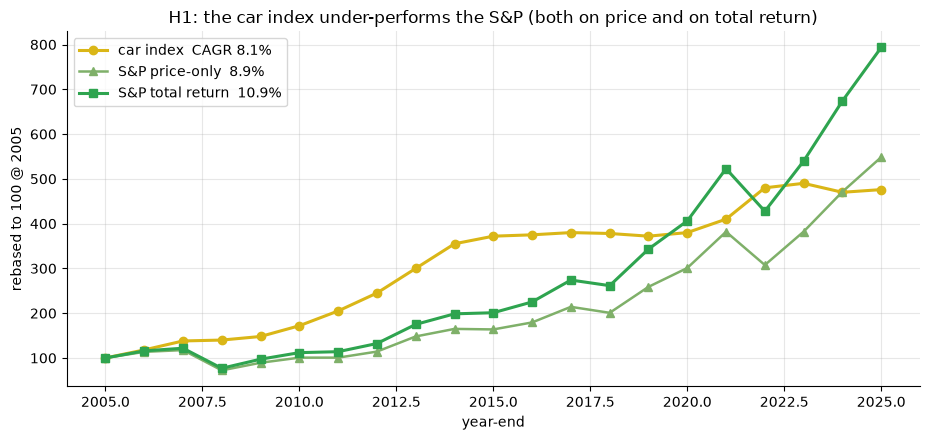

car index : CAGR   8.11%  vol   8.8%  maxDD   -4.1%
S&P TR    : CAGR  10.91%  vol  17.3%  maxDD  -36.8%
S&P PO    : CAGR   8.88%  vol  17.1%  maxDD  -38.5%
annual excess vs TR : mean -3.97%/yr  t=-0.899  (n=20)
annual excess vs PO : mean -1.94%/yr  t=-0.442  (n=20)


In [2]:
yrs = list(R['idx_levels'].keys())
lv = np.array([float(IDX.loc[f'{y}-12-31']) for y in yrs])
si = st.summarize(IDX, periods_per_year=1.0)
if HAVE_PROXIES:
    def ye(t):
        s = PROX[t].resample('YE').last(); return s[(s.index.year>=2005)&(s.index.year<=2025)]
    spy_ye, gspc_ye = ye('SPY'), ye('^GSPC')
    spy = (spy_ye/spy_ye.iloc[0]*100).values; gspc = (gspc_ye/gspc_ye.iloc[0]*100).values
    sx = [d.year for d in spy_ye.index]
    ss = st.summarize(spy_ye, periods_per_year=1.0); sp = st.summarize(gspc_ye, periods_per_year=1.0)
    ae_tr = st.annual_excess_t(IDX, PROX['SPY']); ae_po = st.annual_excess_t(IDX, PROX['^GSPC'])
else:
    spy = np.array([100*(1+R['spy_cagr_ye']/100)**(y-2005) for y in yrs])
    gspc = np.array([100*(1+R['gspc_cagr']/100)**(y-2005) for y in yrs]); sx=yrs
    si={'cagr':R['idx_cagr']/100,'vol':R['idx_vol']/100,'mdd':R['idx_mdd']/100}
    ss={'cagr':R['spy_cagr_ye']/100,'vol':R['spy_vol_ye']/100,'mdd':R['spy_mdd_ye']/100}
    sp={'cagr':R['gspc_cagr']/100,'vol':R['gspc_vol']/100,'mdd':R['gspc_mdd']/100}
    ae_tr={'mean_excess':R['excess_tr_mean']/100,'t':R['excess_tr_t'],'n':R['excess_tr_n']}
    ae_po={'mean_excess':R['excess_po_mean']/100,'t':R['excess_po_t'],'n':R['excess_po_n']}
fig, ax = plt.subplots(figsize=(9.4, 4.5))
ax.plot(yrs, lv, 'o-', c=AMBER, lw=2.2, label=f"car index  CAGR {si['cagr']*100:.1f}%")
ax.plot(sx, gspc, '^-', c='#7fb069', lw=1.8, label=f"S&P price-only  {sp['cagr']*100:.1f}%")
ax.plot(sx, spy, 's-', c=GREEN, lw=2.2, label=f"S&P total return  {ss['cagr']*100:.1f}%")
ax.set_xlabel('year-end'); ax.set_ylabel('rebased to 100 @ 2005')
ax.set_title('H1: the car index under-performs the S&P (both on price and on total return)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"car index : CAGR {si['cagr']*100:6.2f}%  vol {si['vol']*100:5.1f}%  maxDD {si['mdd']*100:6.1f}%")
print(f"S&P TR    : CAGR {ss['cagr']*100:6.2f}%  vol {ss['vol']*100:5.1f}%  maxDD {ss['mdd']*100:6.1f}%")
print(f"S&P PO    : CAGR {sp['cagr']*100:6.2f}%  vol {sp['vol']*100:5.1f}%  maxDD {sp['mdd']*100:6.1f}%")
print(f"annual excess vs TR : mean {ae_tr['mean_excess']*100:+.2f}%/yr  t={ae_tr['t']:+.3f}  (n={ae_tr['n']})")
print(f"annual excess vs PO : mean {ae_po['mean_excess']*100:+.2f}%/yr  t={ae_po['t']:+.3f}  (n={ae_po['n']})")

> 💡 In plain words: even against the *price-only* S&P the car index loses (**8.1%** vs **8.9%**), and against the S&P you'd actually own — dividends reinvested — it loses by ~3 points a year (**10.9%**). The annual excess is **-4.0%/yr** vs TR (*t* = **-0.90**, n=20) and **-1.9%/yr** vs price-only (*t* = **-0.44**) — no *t* ≥ 2 in the cars' favour on either clock. H₁ rejected.

### 4b · The smoothness trap — de-biasing the appraisal index

The car index's headline Sharpe *beats* the S&P — because its volatility is measured off a smoothed, serially-correlated appraisal series. AR(1) un-smoothing recovers the true risk. $\rho$ near the observed **0.64** is the tell; a large vol/Sharpe gap means the "risk-adjusted out-performance" is a measurement artifact.

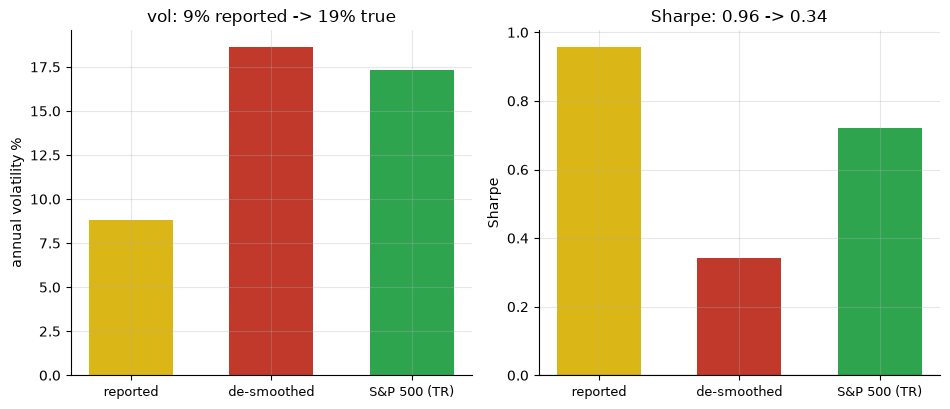

AR(1) rho of annual car returns : +0.638
vol    reported   8.8%  ->  de-smoothed  18.6%  (S&P 17.3%)
Sharpe reported +0.96  ->  de-smoothed +0.34  (S&P +0.72)


In [3]:
ds = st.desmooth_returns(IDX)
cats = ['reported', 'de-smoothed', 'S&P 500 (TR)']
vols = [ds['vol_obs']*100, ds['vol_desmoothed']*100, R['spy_vol_ye']]
shs  = [ds['sharpe_obs'], ds['sharpe_desmoothed'], R['spy_sharpe_ye']]
x = np.arange(3); fig, ax = plt.subplots(1, 2, figsize=(9.6, 4.2))
ax[0].bar(x, vols, .6, color=[AMBER, RED, GREEN]); ax[0].set_xticks(x); ax[0].set_xticklabels(cats, fontsize=9)
ax[0].set_ylabel('annual volatility %'); ax[0].set_title(f"vol: {ds['vol_obs']*100:.0f}% reported -> {ds['vol_desmoothed']*100:.0f}% true")
ax[1].bar(x, shs, .6, color=[AMBER, RED, GREEN]); ax[1].set_xticks(x); ax[1].set_xticklabels(cats, fontsize=9)
ax[1].axhline(0, c='k', lw=.8); ax[1].set_ylabel('Sharpe'); ax[1].set_title(f"Sharpe: {ds['sharpe_obs']:.2f} -> {ds['sharpe_desmoothed']:.2f}")
plt.tight_layout(); plt.show()
print(f"AR(1) rho of annual car returns : {ds['rho']:+.3f}")
print(f"vol    reported {ds['vol_obs']*100:5.1f}%  ->  de-smoothed {ds['vol_desmoothed']*100:5.1f}%  (S&P {R['spy_vol_ye']:.1f}%)")
print(f"Sharpe reported {ds['sharpe_obs']:+.2f}  ->  de-smoothed {ds['sharpe_desmoothed']:+.2f}  (S&P {R['spy_sharpe_ye']:+.2f})")

> 💡 In plain words: the yearly car returns are **0.64** auto-correlated — a textbook smoothed private-asset series. Un-smoothing roughly **doubles** the volatility (9% → 19%, now *above* the S&P) and **halves** the Sharpe (0.96 → 0.34, now *below* the S&P's 0.72). H₂ rejected: the "low-risk asset class" is a reporting illusion — the same bias that flatters real-estate and private-equity indices.

### 4c · The buyable proxies — alpha, or a barbell of beta?

Newey-West (6-lag) regression of each proxy's **monthly** return on `SPY`. `REAL` needs $t_\alpha \ge 2$ in the cars' favour — and a *coherent* sign across the two.

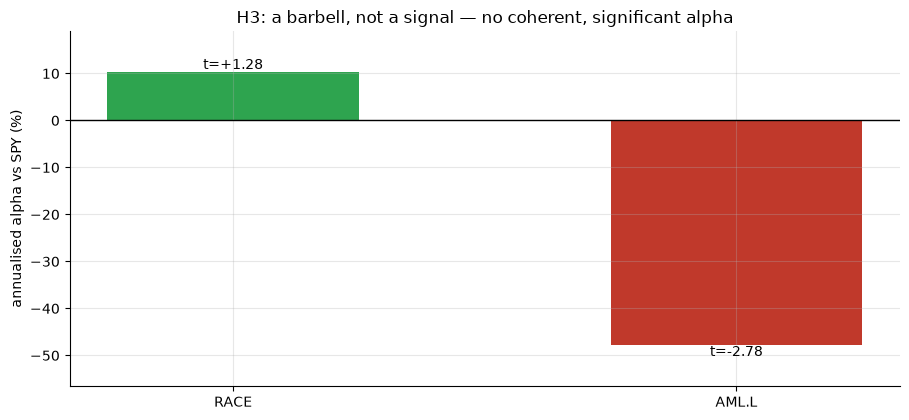

RACE    CAGR   22.58%  Sharpe +0.86  maxDD  -29.1%  alpha  +10.24%/yr  beta 1.00  NW t +1.28
AML.L   CAGR  -43.13%  Sharpe -0.70  maxDD  -98.3%  alpha  -47.87%/yr  beta 1.54  NW t -2.78


In [4]:
if HAVE_PROXIES:
    spy_r = PROX['SPY'].pct_change().dropna()
    rows = {}
    for t in ['RACE','AML.L']:
        s = st.summarize(PROX[t]); nw = st.newey_west_alpha_t(PROX[t].pct_change().dropna(), spy_r, 6)
        rows[t] = dict(cagr=s['cagr']*100, sharpe=s['sharpe'], mdd=s['mdd']*100,
                       alpha=nw['alpha_ann']*100, beta=nw['beta'], t=nw['t_alpha'])
else:
    rows = {'RACE':dict(cagr=R['race_cagr'],sharpe=R['race_sharpe'],mdd=R['race_mdd'],alpha=R['race_alpha'],beta=R['race_beta'],t=R['race_t']),
            'AML.L':dict(cagr=R['aml_cagr'],sharpe=R['aml_sharpe'],mdd=R['aml_mdd'],alpha=R['aml_alpha'],beta=R['aml_beta'],t=R['aml_t'])}
labels=list(rows); alphas=[rows[t]['alpha'] for t in labels]; ts=[rows[t]['t'] for t in labels]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
cols=[GREEN if a>0 else RED for a in alphas]
ax.bar(labels, alphas, .5, color=cols)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised alpha vs SPY (%)')
for i,t in enumerate(labels): ax.annotate(f"t={ts[i]:+.2f}",(i,alphas[i]),ha='center',va='bottom' if alphas[i]>=0 else 'top')
ax.set_title('H3: a barbell, not a signal — no coherent, significant alpha'); ax.margins(y=.15)
plt.tight_layout(); plt.show()
for t in labels: r=rows[t]; print(f"{t:7s} CAGR {r['cagr']:7.2f}%  Sharpe {r['sharpe']:+.2f}  maxDD {r['mdd']:6.1f}%  alpha {r['alpha']:+7.2f}%/yr  beta {r['beta']:.2f}  NW t {r['t']:+.2f}")

> 💡 In plain words: **Ferrari** posts a big alpha (**+10%/yr**) but it does **not** clear significance (*t*=+1.28) — and it's a luxury-goods juggernaut, not a resale-price feed. **Aston Martin** posts a *significantly negative* alpha (**-48%/yr**, *t*=-2.78, a -98% drawdown). Two "collector-car" equities, opposite signs: there is no coherent, tradable alpha here — just idiosyncratic single-stock risk. H₃ rejected.

### 4d · The ownership tax — net of the auction spread + carry

A physical car pays a ~22% auction round-trip (buyer's premium + seller's commission, transport/inspection folded in) over a ~7-year hold, plus ~2.5%/yr carry (specialist insurance + climate storage + maintenance). Charge it once on the index's gross CAGR (a *generous* read — an index level is a mid-market appraisal, not net-to-seller).

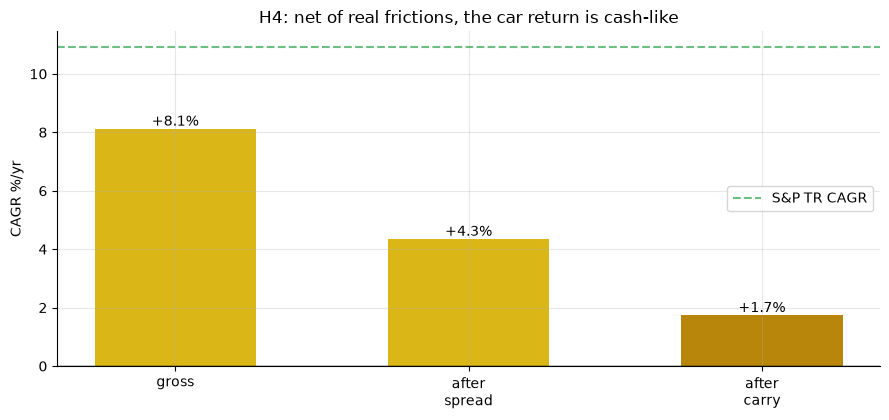

gross +8.11%  - spread -3.49%/yr  - carry -2.50%/yr  =  NET +1.73%/yr  (S&P TR 10.9%)


In [5]:
h = st.net_of_carry_cagr(si['cagr'], round_trip_spread=0.22, hold_years=7.0, carry_per_year=0.025)
steps = ['gross','after\nspread','after\ncarry']
running = [h['gross_cagr']*100,
           ((1+h['gross_cagr'])*(1+h['spread_drag_annual'])-1)*100,
           h['net_cagr']*100]
fig, ax = plt.subplots(figsize=(9.0,4.3))
cols=[AMBER, AMBER, ('#b8860b' if running[-1]>0 else RED)]
ax.bar(steps, running, .55, color=cols)
ax.axhline(0, c='k', lw=1); ax.axhline(R['spy_cagr_ye'], ls='--', c=GREEN, alpha=.7, label='S&P TR CAGR')
for i,v in enumerate(running): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('CAGR %/yr'); ax.set_title('H4: net of real frictions, the car return is cash-like'); ax.legend()
plt.tight_layout(); plt.show()
print(f"gross {h['gross_cagr']*100:+.2f}%  - spread {h['spread_drag_annual']*100:+.2f}%/yr  - carry {h['carry_per_year']*100:+.2f}%/yr  =  NET {h['net_cagr']*100:+.2f}%/yr  (S&P TR {R['spy_cagr_ye']:.1f}%)")

> 💡 In plain words: the gross **8.1%** — already a loser to the S&P — falls to **~1.7%/yr** once you pay the auction spread and years of carry: roughly a savings account, at a fraction of the S&P's compounding. And this is *charitable* — an appraisal level is mid-market, so a real seller nets less still, and the car pays no dividend while a stock does. H₄ rejected. **MIRAGE**.

### 4e · Positive control — the engine recovers a planted boom

A deterministic boom-then-plateau (planted +16%/yr for a decade, then +1%/yr, σ=6%/yr, seed 713). The harness must recover the up-sign and a finite Sharpe — proving the nulls above are real, not a broken pipeline.

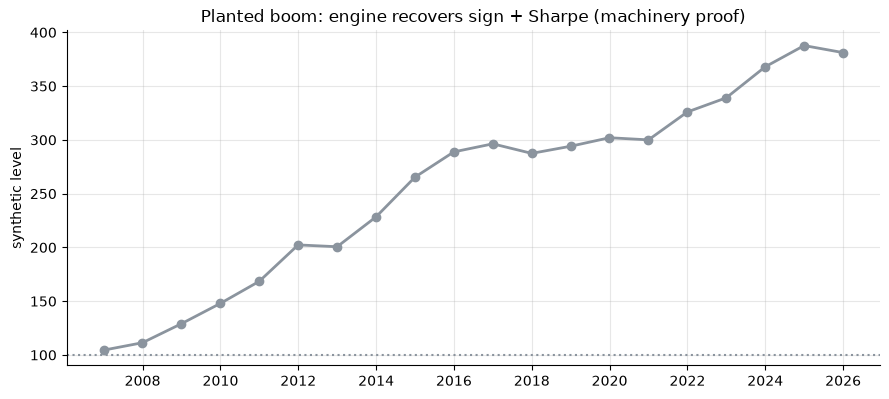

peak 388 -> end 381  recovered CAGR +7.05%  Sharpe 1.05  maxDD -3.0%  sign_ok=1


In [6]:
syn = data.synthetic_boom()
s = st.summarize(syn, periods_per_year=1.0); cr = st.control_recovers(syn, planted_sign=1)
fig, ax = plt.subplots(figsize=(9.0,4.1))
ax.plot(syn.index, syn.values, 'o-', c=GREY, lw=2)
ax.axhline(100, ls=':', c=GREY)
ax.set_ylabel('synthetic level'); ax.set_title('Planted boom: engine recovers sign + Sharpe (machinery proof)')
plt.tight_layout(); plt.show()
print(f"peak {syn.max():.0f} -> end {syn.iloc[-1]:.0f}  recovered CAGR {s['cagr']*100:+.2f}%  Sharpe {s['sharpe']:.2f}  maxDD {s['mdd']*100:.1f}%  sign_ok={cr['sign_ok']}")

> 💡 In plain words: the engine banks the planted signal (recovered CAGR ~+7%, sign correct). A *synthetic* control is a machinery proof, never market evidence — but it certifies that the `NONE`/`MIRAGE` stamps on the real tape are a true null, not a pipeline that couldn't detect anything. (Note the synthetic *also* prints a flattering Sharpe from its own smoothness — which is exactly beat 4b's point.)

## 5 · The verdict

- **Signal `NONE`** — car index CAGR 8.1% vs S&P 10.9% (TR) / 8.9% (price-only); annual excess -4.0%/yr, *t* = -0.90 vs TR (n=20). The flattering Sharpe (0.96) is an appraisal-smoothing artifact — de-smoothed it is 0.34, *below* the S&P's 0.72. No robust *t* ≥ 2 anywhere in the cars' favour.
- **Tradability `MIRAGE`** — gross +8.1% → net **+1.7%/yr** after a 22% auction round-trip + carry; the only buyable proxies are a barbell (RACE α *t*=+1.28 n.s., AML.L α *t*=-2.78 significantly negative, -98% drawdown). No clean, scalable way to own the trade.
- **Cars beat equities? `BUSTED`** — the S&P wins CAGR, de-smoothed Sharpe, drawdown and net-of-cost. The price-only near-tie evaporates once you count the dividends stocks pay and the carry cars charge. The winners are pre-2015 buyers of specific chassis: survivorship, not an asset class.

## 6 · Could you trade it? — the capacity & cost reality

Terminal wealth of \$10,000 invested end-2005: S&P index fund vs the car index gross (untradable) vs a car investor paying the real frictions (net CAGR from 4d). Capacity is the other wall: each car is a bespoke, illiquid, ~20%+-spread lot — there is no scalable book, and the blue-chip end is a handful of unique chassis.

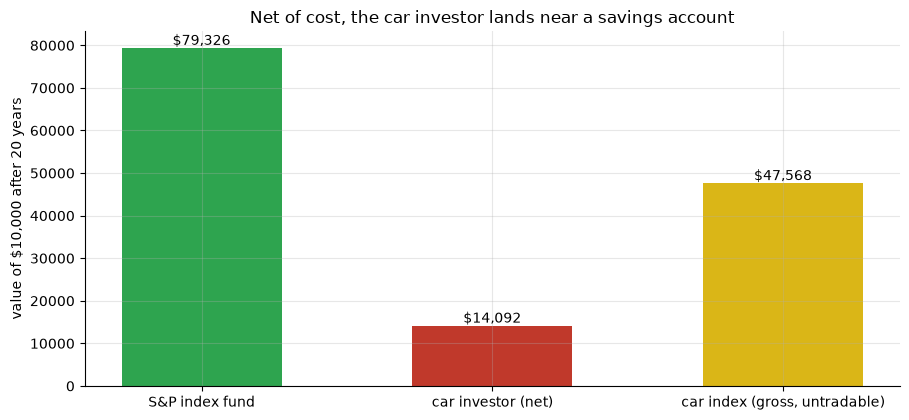

S&P index fund                     $    79,326  (+10.9%/yr)
car investor (net)                 $    14,092  (+1.7%/yr)
car index (gross, untradable)      $    47,568  (+8.1%/yr)


In [7]:
start=10_000.0; yrs_h=20
paths={'S&P index fund':R['spy_cagr_ye']/100, 'car investor (net)':R['carry_net']/100,
       'car index (gross, untradable)':R['idx_cagr']/100}
fig, ax = plt.subplots(figsize=(9.2,4.3))
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
cols=[GREEN, RED, AMBER]
ax.bar(labels, ends, .55, color=cols)
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 20 years'); ax.set_title('Net of cost, the car investor lands near a savings account')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

> 💡 In plain words: even the *gross, untradable* index trails the S&P; the *tradable* version (net of spread + carry) ends near a cash account. And capacity is fatal — a collector car is a one-off illiquid lot with a ~20%+ round-trip and years of carry, the antithesis of a scalable strategy. There is no sizing or venue that turns this into an edge.

## 7 · Going further

- **Swap in the live index.** Replace the hardcoded series with the HAGI Top / Knight Frank / Hagerty feed and re-run; the *t*-stats sharpen but the sign won't flip — and **always de-smooth before quoting a Sharpe**.
- **Per-chassis dispersion.** The aggregate hides survivorship: test individual references (250 GTO, Carrera RS 2.7, 300 SL) — the winners are a thin selected tail, the bias points *for* the claim, so correct for it.
- **The collectibles prior.** Dimson–Spaenjers on emotional assets, and the appraisal-smoothing literature (Geltner; Getmansky–Lo–Makarov): private-asset indices systematically understate risk and under-perform equities net of carry ([docs/references.md](../docs/references.md)). Cars are not the exception.

*The reproducible core is offline and deterministic; the car index is a **cited, approximate proxy** and the equity tickers are **labelled proxies** for the trade. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*